# Regret calculation
First the decision tree must be used in the notebook "main" to crate the thresholds for the different strategies.Then the model must be rerun with the additional constraint given from the decision tree. Foe example the cluster 0 has above 250 TWh/a of biomass use for crudeOil production. Therefore all scenarios belonging to cluster 1 must be rerun with the additional constraint of using at least 250 TWh/a of biomass for crudeOil production. The needed output of EuSysmod is a csv file containing the total cost for the scenarios which will be compared with the total cost of the same scenario without the additional constraint.

Make sure that the following files are in the data folder:
- total_cost.csv (from the uncostrained optimization)
- total_cost_cluster_0 (from all the scenarios not belonging to cluster 0 and the additional constraint)
- total_cost_cluster_1 (...)
- ...

Now import all the needed libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate


Read the files and calculate the regret

In [2]:
# Read the CSV file with the unconstrained total cost
df_total_cost = pd.read_csv("data/merged_total_cost.csv", sep=",") 


# Create a dictionary to store the regret cost for each cluster
regret_cost = dict()

files = ["merged_total_cost_cluster_0.csv",
         "merged_total_cost_cluster_1.csv",
         "merged_total_cost_cluster_2.csv",
         "merged_total_cost_allLTH.csv",
         "merged_total_cost_noBiomass.csv",
         "merged_total_cost_onlyHvcAndOil.csv"]

names = ["cluster0",
            "cluster1",
            "cluster2",
            "allLTH",
            "noBiomass",
            "HVC_and_Oil"]

# for cluster in range(NUMBER_OF_CLUSTERS):   
for file, name in zip(files, names):
    # Read the CSV file for the cluster
    total_cost_cluster = pd.read_csv("data/" + file, sep=",") 
    print(name,":", len(total_cost_cluster))

    # Create a list in the dictionary for each cluster
    regret_cost[name] = [] 
    
    # iterate over each scenario and add the regret cost to the list in the dictionary
    for scenario in range(1, 1+len(df_total_cost)):
        if scenario in total_cost_cluster['iteration'].values:
             regret_cost[name].append( 
                total_cost_cluster[total_cost_cluster['iteration'] == scenario]["objectiveValue"].values[0] -
                df_total_cost[df_total_cost['iteration'] == scenario]["objectiveValue"].values[0]
            )
        else:
             regret_cost[name].append(0)



cluster0 : 834
cluster1 : 250
cluster2 : 916
allLTH : 1000
noBiomass : 1000
HVC_and_Oil : 1000


In [3]:
df_regret_cost = pd.DataFrame.from_dict(regret_cost)
df_regret_cost

,cluster0,cluster1,cluster2,allLTH,noBiomass,HVC_and_Oil
0,4442.891512,3463.809451,0.000000,43837.595054,20636.006682,-0.275864
1,7808.081498,0.000000,7709.239733,53441.486760,44326.025201,-0.600125
2,0.000000,3808.921629,6947.136497,14596.439319,317.141644,154.927052
3,0.000000,4177.984040,3489.991463,21694.642672,885.527975,2.868849
4,10161.411947,4540.780020,0.000000,58214.579236,44536.425591,0.071590
...,...,...,...,...,...,...
995,20504.697204,0.000000,10290.923008,87528.314310,61267.827225,-0.078993
996,6861.451722,1778.056415,0.000000,54491.792011,39655.937370,0.531460
997,10649.318182,155.619324,0.000000,64523.746919,47466.048516,-0.032006
998,6140.097739,11.468621,0.000000,44336.427517,25587.619401,0.268001


Create a table, a boxplot and images to visualize the regret values:

In [4]:
data = [
    ['Strategy', 'Max Regret', 'Average Regret', 'Optimal Scenarios'],
    ['regret cluster 1', int(df_regret_cost['cluster1'].max()), int(df_regret_cost['cluster1'].mean()), len(df_regret_cost[df_regret_cost['cluster1'] == 0])],
    ['regret cluster 2', int(df_regret_cost['cluster2'].max()), int(df_regret_cost['cluster2'].mean()), len(df_regret_cost[df_regret_cost['cluster2'] == 0])],
    ['regret cluster 0', int(df_regret_cost['cluster0'].max()), int(df_regret_cost['cluster0'].mean()), len(df_regret_cost[df_regret_cost['cluster0'] == 0])],
    ['regret allLTH', int(df_regret_cost['allLTH'].max()), int(df_regret_cost['allLTH'].mean()), len(df_regret_cost[df_regret_cost['allLTH'] < 5])],
    ['regret noBiomass', int(df_regret_cost['noBiomass'].max()), int(df_regret_cost['noBiomass'].mean()), len(df_regret_cost[df_regret_cost['noBiomass'] < 5])],
    ['regret HVC_and_Oil', int(df_regret_cost['HVC_and_Oil'].max()), int(df_regret_cost['HVC_and_Oil'].mean()), len(df_regret_cost[df_regret_cost['HVC_and_Oil'] < 5])]
]

headers = data[0]
table_data = data[1:]

table = tabulate(table_data, headers, tablefmt='grid')
print(table)


+--------------------+--------------+------------------+---------------------+
| Strategy           |   Max Regret |   Average Regret |   Optimal Scenarios |
+====================+==============+==================+=====================+
| regret cluster 1   |         7209 |              498 |                 750 |
+--------------------+--------------+------------------+---------------------+
| regret cluster 2   |        19710 |             4898 |                  84 |
+--------------------+--------------+------------------+---------------------+
| regret cluster 0   |        30881 |             6454 |                 166 |
+--------------------+--------------+------------------+---------------------+
| regret allLTH      |       116961 |            49077 |                   0 |
+--------------------+--------------+------------------+---------------------+
| regret noBiomass   |        95127 |            32844 |                   0 |
+--------------------+--------------+---------------

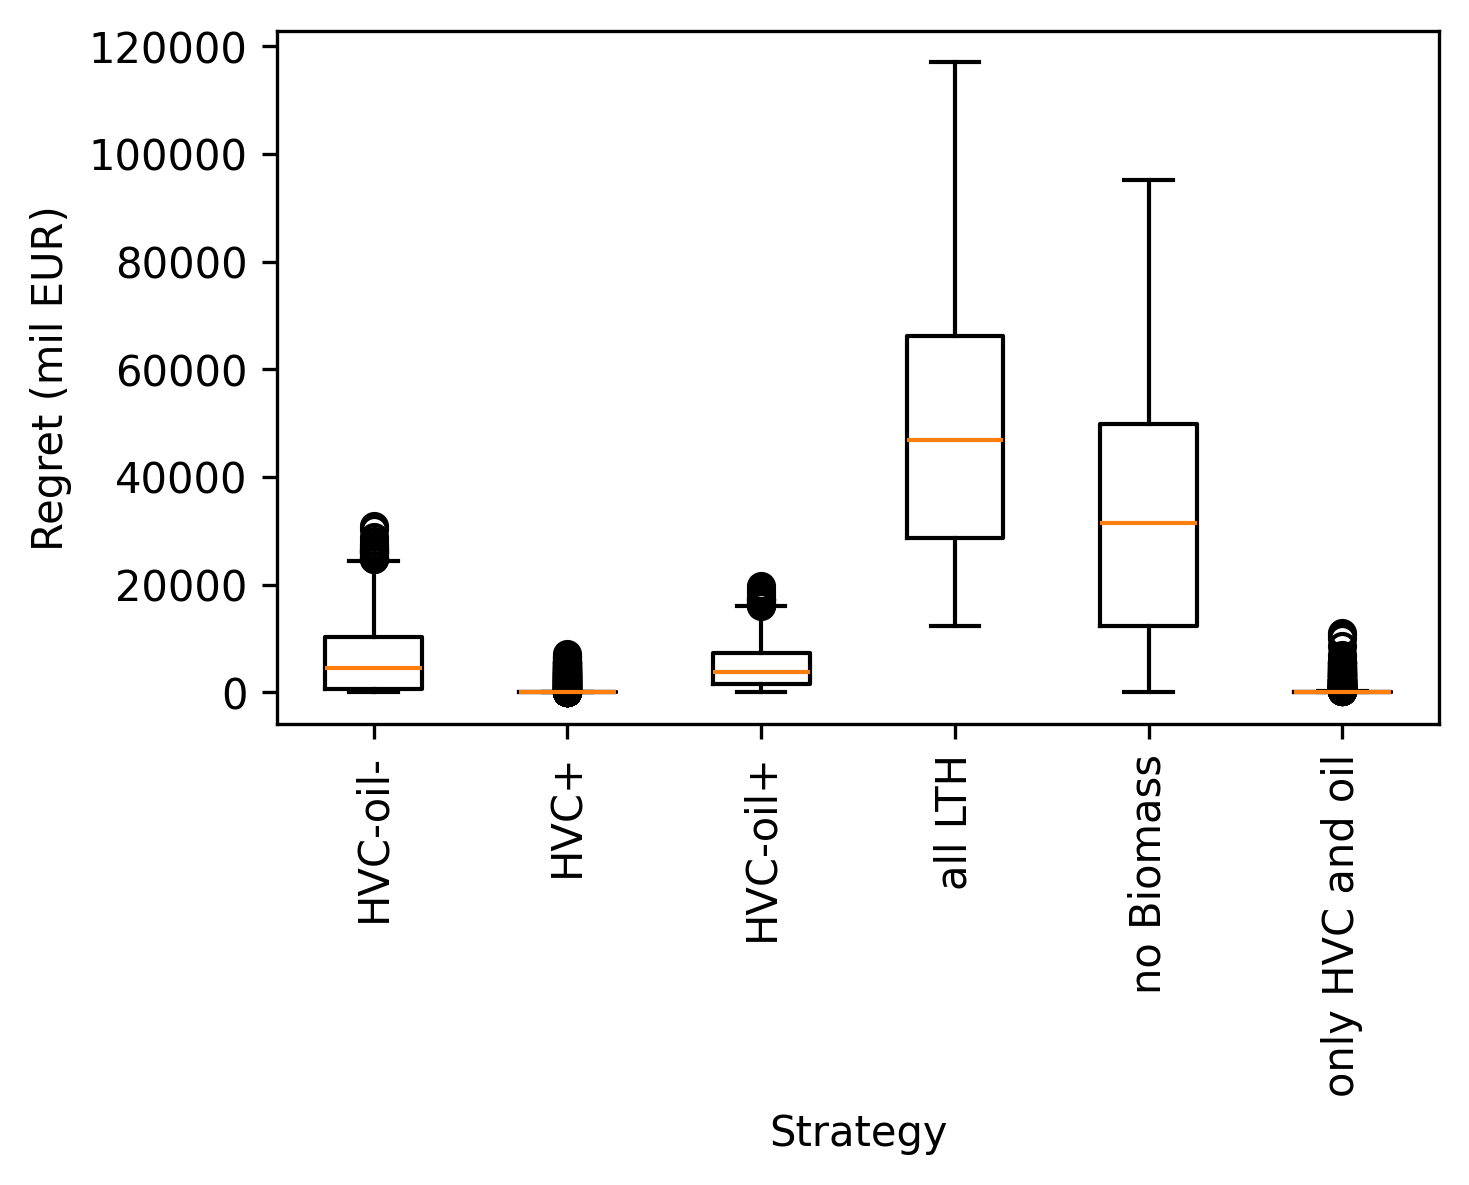

In [5]:
# Create a boxplot
plt.figure(figsize=(5, 3), dpi=300)
plt.boxplot(df_regret_cost.values)
# The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers.

# Set the x-axis tick labels
plt.xticks(range(1, len(df_regret_cost.columns) + 1), ['HVC-oil-', 'HVC+', 'HVC-oil+', 'all LTH', 'no Biomass', 'only HVC and oil'], rotation=90)
                                                       
# Set the y-axis label
plt.ylabel('Regret (mil EUR)')
plt.xlabel('Strategy')

plt.show()

In [6]:
STRATEGY_NAMES = {1: 'Strategy HVC+', 2: 'Strategy HVC- oil+', 0: 'Strategy HVC- oil-'}
COLOR_MAP = {1: 'blue', 2: 'darkviolet', 0: 'darkgreen'}

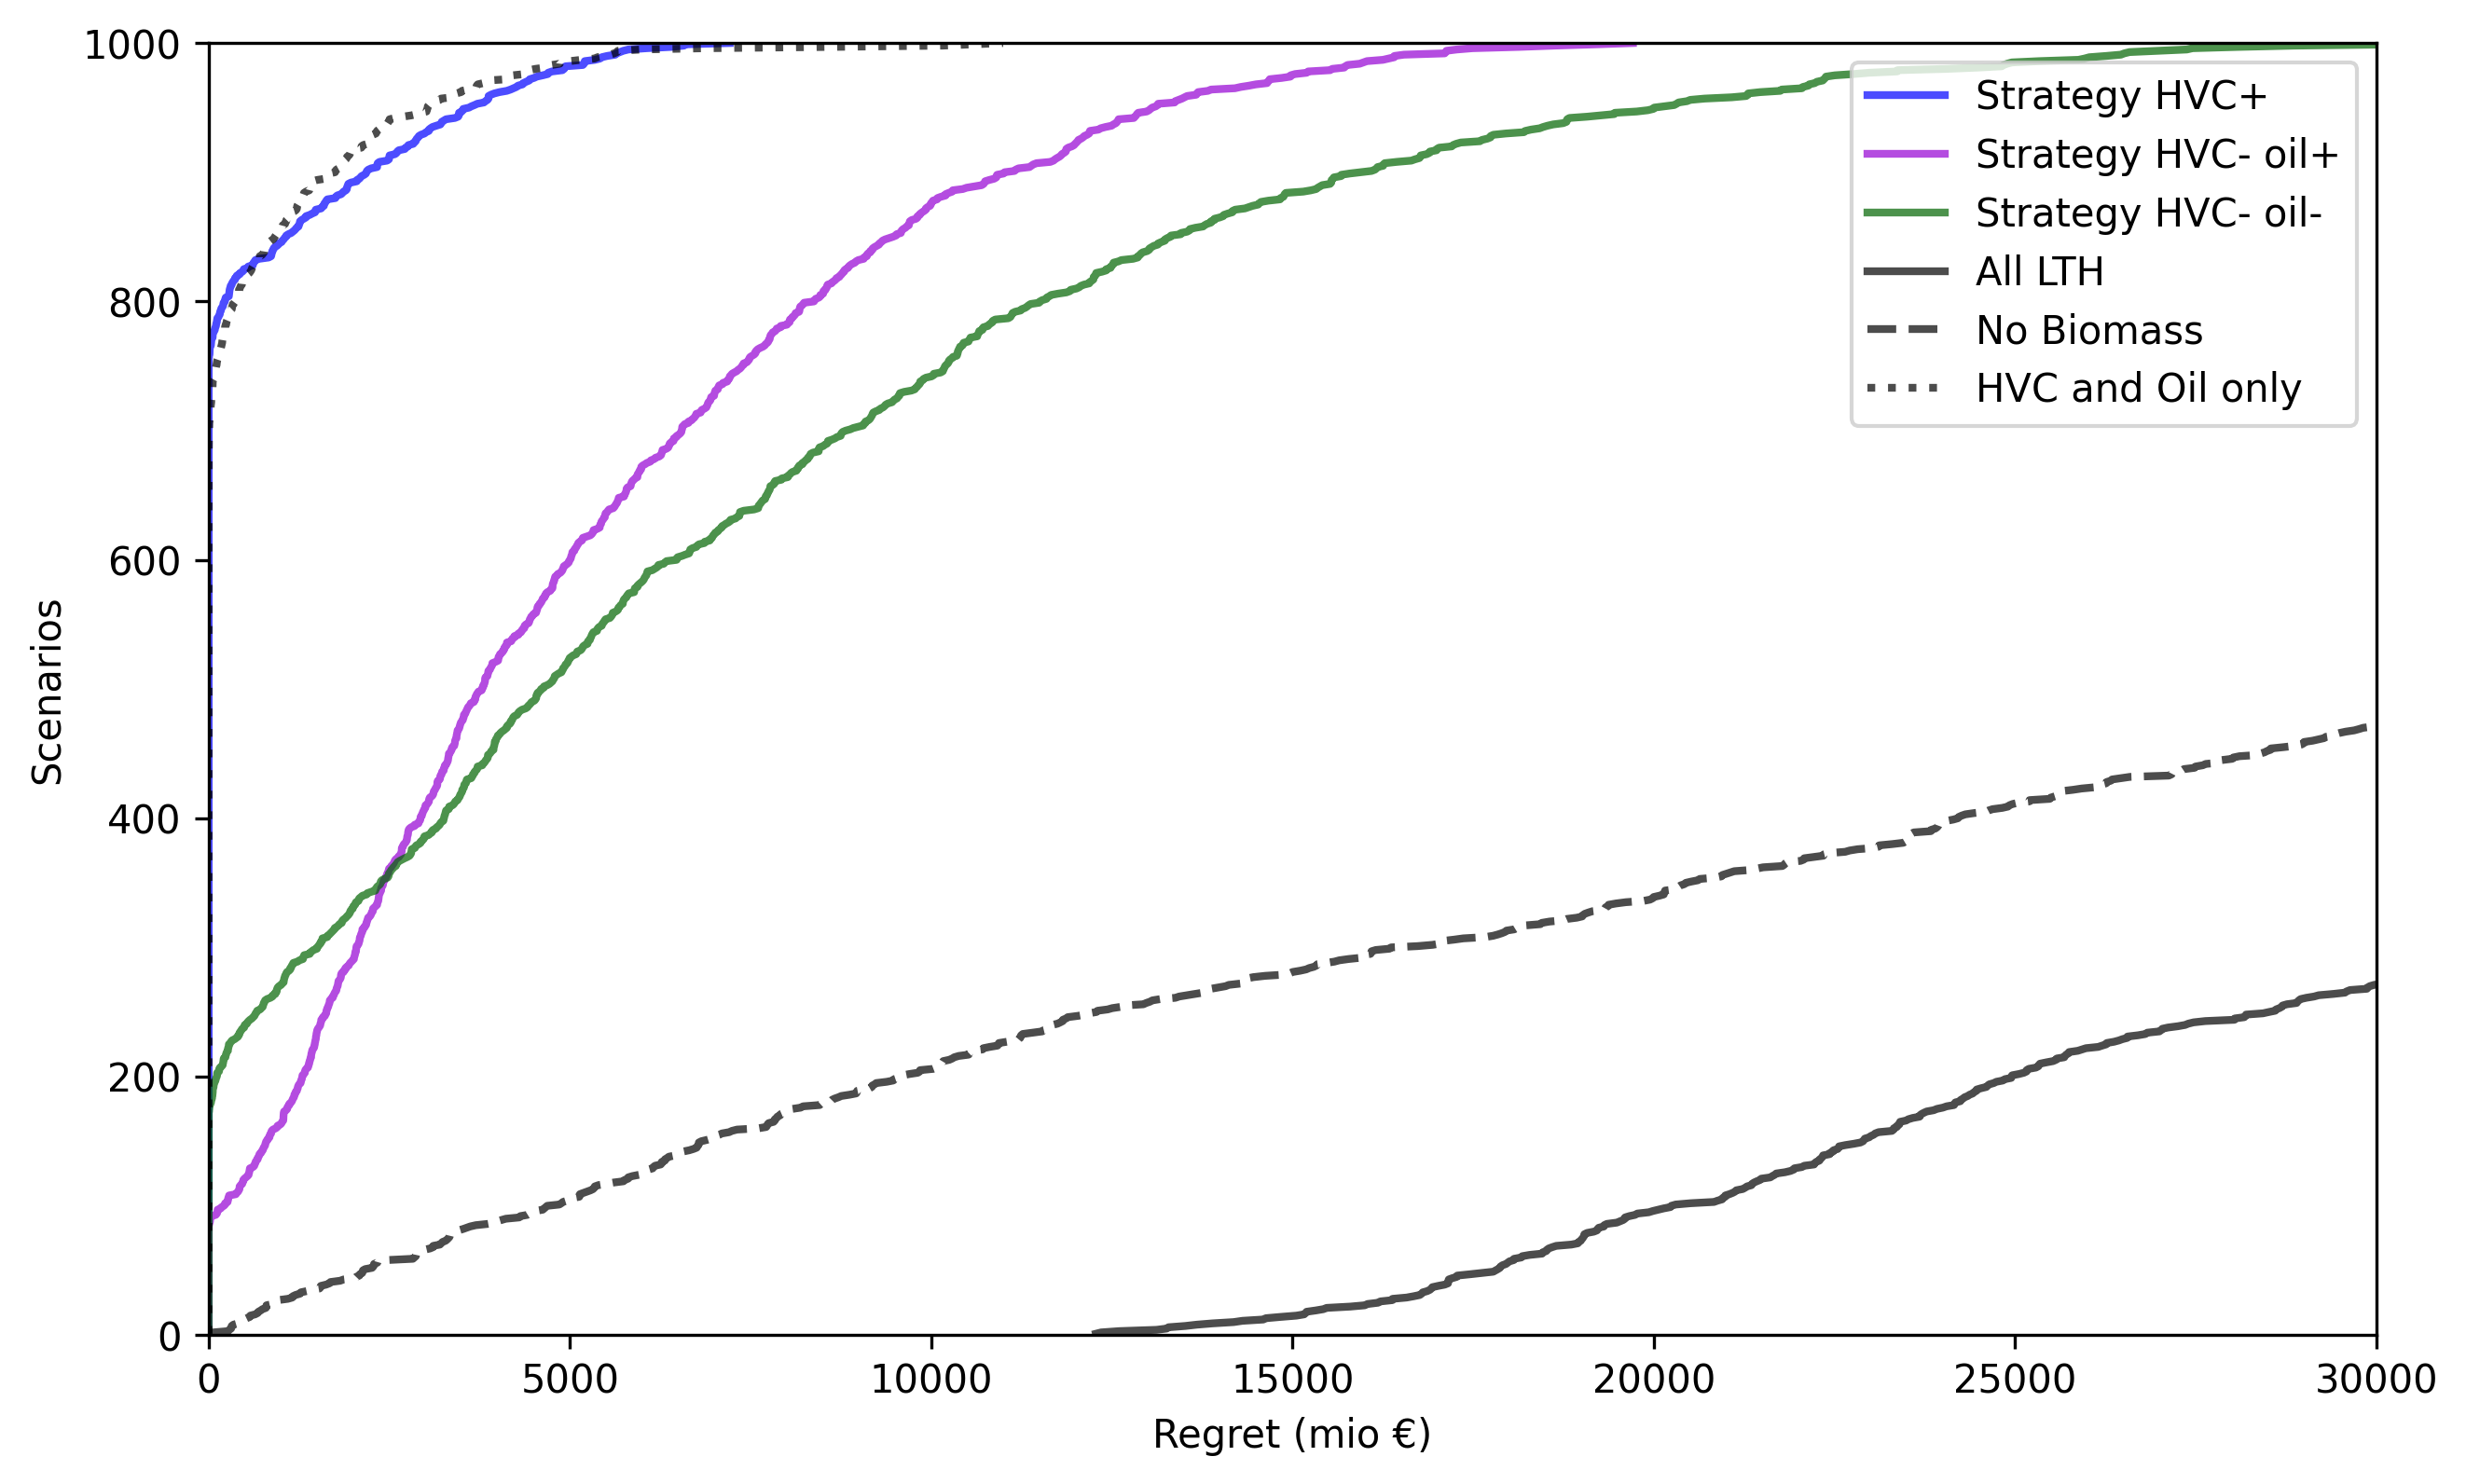

In [7]:

scnarios = np.arange(1, len( regret_cost[f"cluster0"]) + 1) # Create an array for the y-axis values

# Plot the data
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(np.sort(regret_cost["cluster1"]), scnarios, color=COLOR_MAP[1], alpha=0.7, linestyle='-', linewidth=2, label=STRATEGY_NAMES[1])
plt.plot(np.sort(regret_cost["cluster2"]), scnarios, color=COLOR_MAP[2], alpha=0.7, linestyle='-', linewidth=2, label=STRATEGY_NAMES[2])
plt.plot(np.sort(regret_cost["cluster0"]), scnarios, color=COLOR_MAP[0], alpha=0.7, linestyle='-', linewidth=2, label=STRATEGY_NAMES[0])
plt.plot(np.sort(regret_cost["allLTH"]), scnarios, color='black', alpha=0.7, linestyle='-', linewidth=2, label='All LTH')
plt.plot(np.sort(regret_cost["noBiomass"]), scnarios, color='black', alpha=0.7, linestyle='--', linewidth=2, label='No Biomass')
plt.plot(np.sort(regret_cost["HVC_and_Oil"]), scnarios, color='black', alpha=0.7, linestyle=':', linewidth=2, label='HVC and Oil only')


# Set the y-axis limits
plt.ylim(0, len(df_total_cost))
plt.xlim(0, 30000)

# Set labels
plt.xlabel('Regret (mio €)')
plt.ylabel('Scenarios')

# Add a legend
plt.legend(loc='upper right')

# plt.savefig("results/regret.svg",  format="svg")
# plt.savefig("results/regret.pdf")

plt.show()


# Create scatter plots to show the usage of biomass with and without constraints

Prepare Data: make sure that the respective files are in the "data" folder:
- merged_outputsOfInterest.csv
- merged_outputsOfInterest_cluster_0.csv
- ...

In [8]:
df_output_of_interest_optimal_with_iteration = pd.read_csv(r"data\merged_outputsOfInterest.csv", sep=",") # Read the CSV file

## combine categories
df_output_of_interest_optimal_with_iteration['LTH'] = df_output_of_interest_optimal_with_iteration['LTH'] + df_output_of_interest_optimal_with_iteration['DH'] + df_output_of_interest_optimal_with_iteration['SpaceHeating'] # Combine 'LTH', 'DH', and 'SpaceHeating' columns
df_output_of_interest_optimal_with_iteration = df_output_of_interest_optimal_with_iteration.drop(columns=['DH', 'SpaceHeating']) # Drop the original 'DH' and 'SpaceHeating' columns
df_output_of_interest_optimal_with_iteration['HTH'] = df_output_of_interest_optimal_with_iteration['MTH'] + df_output_of_interest_optimal_with_iteration['HTH'] # Combine 'MTH' and 'HTH' 
df_output_of_interest_optimal_with_iteration = df_output_of_interest_optimal_with_iteration.drop(columns=['MTH']) # Drop the original 'DH' and 'SpaceHeating' columns

## rename crudeOil / biogas
df_output_of_interest_optimal_with_iteration = df_output_of_interest_optimal_with_iteration.rename(columns={"crudeOil": "oil"})
df_output_of_interest_optimal_with_iteration = df_output_of_interest_optimal_with_iteration.rename(columns={"rawBiogas": "biogas"})

df_output_of_interest_optimal_with_iteration = df_output_of_interest_optimal_with_iteration.abs() # Take the absolute value of all columns


In [9]:

def process_output_of_interest_data(csv_path, df_output_of_interest_optimal_with_iteration):
    # Read the CSV file for the specific cluster
    df_cluster = pd.read_csv(csv_path, sep=",")
    
    # Take the absolute value of all columns
    df_cluster = df_cluster.abs()
    
    # Combine categories
    df_cluster['LTH'] = df_cluster['LTH'] + df_cluster['DH'] + df_cluster['SpaceHeating']
    df_cluster = df_cluster.drop(columns=['DH', 'SpaceHeating'])
    
    df_cluster['HTH'] = df_cluster['MTH'] + df_cluster['HTH']
    df_cluster = df_cluster.drop(columns=['MTH'])
    
    # Rename crudeOil / biogas
    df_cluster = df_cluster.rename(columns={"crudeOil": "oil", "rawBiogas": "biogas"})
    
    # Find the missing iterations
    missing_iterations = set(range(1, 1001)) - set(df_cluster['iteration'])
    
    # Create a DataFrame with the missing iterations from df_output_of_interest_optimal_with_iteration
    missing_df = df_output_of_interest_optimal_with_iteration[df_output_of_interest_optimal_with_iteration['iteration'].isin(missing_iterations)].copy()
    
    # Concatenate the missing DataFrame with the original DataFrame
    df_cluster = pd.concat([df_cluster, missing_df], ignore_index=True)
    
    # Sort the DataFrame by iteration
    df_cluster = df_cluster.sort_values('iteration')
    
    # Fill the missing values with zeros
    df_cluster = df_cluster.fillna(0)
    
    # Take the absolute value of all columns again, if needed
    df_cluster = df_cluster.abs()
    
    return df_cluster


# Process cluster 0
df_output_of_interest_cluster_0_with_iteration = process_output_of_interest_data(r"data\merged_outputsOfInterest_cluster_0.csv", df_output_of_interest_optimal_with_iteration)

# Process cluster 1
df_output_of_interest_cluster_1_with_iteration = process_output_of_interest_data(r"data\merged_outputsOfInterest_cluster_1.csv", df_output_of_interest_optimal_with_iteration)

# Process cluster 2
df_output_of_interest_cluster_2_with_iteration = process_output_of_interest_data(r"data\merged_outputsOfInterest_cluster_2.csv", df_output_of_interest_optimal_with_iteration)

Create Figure:

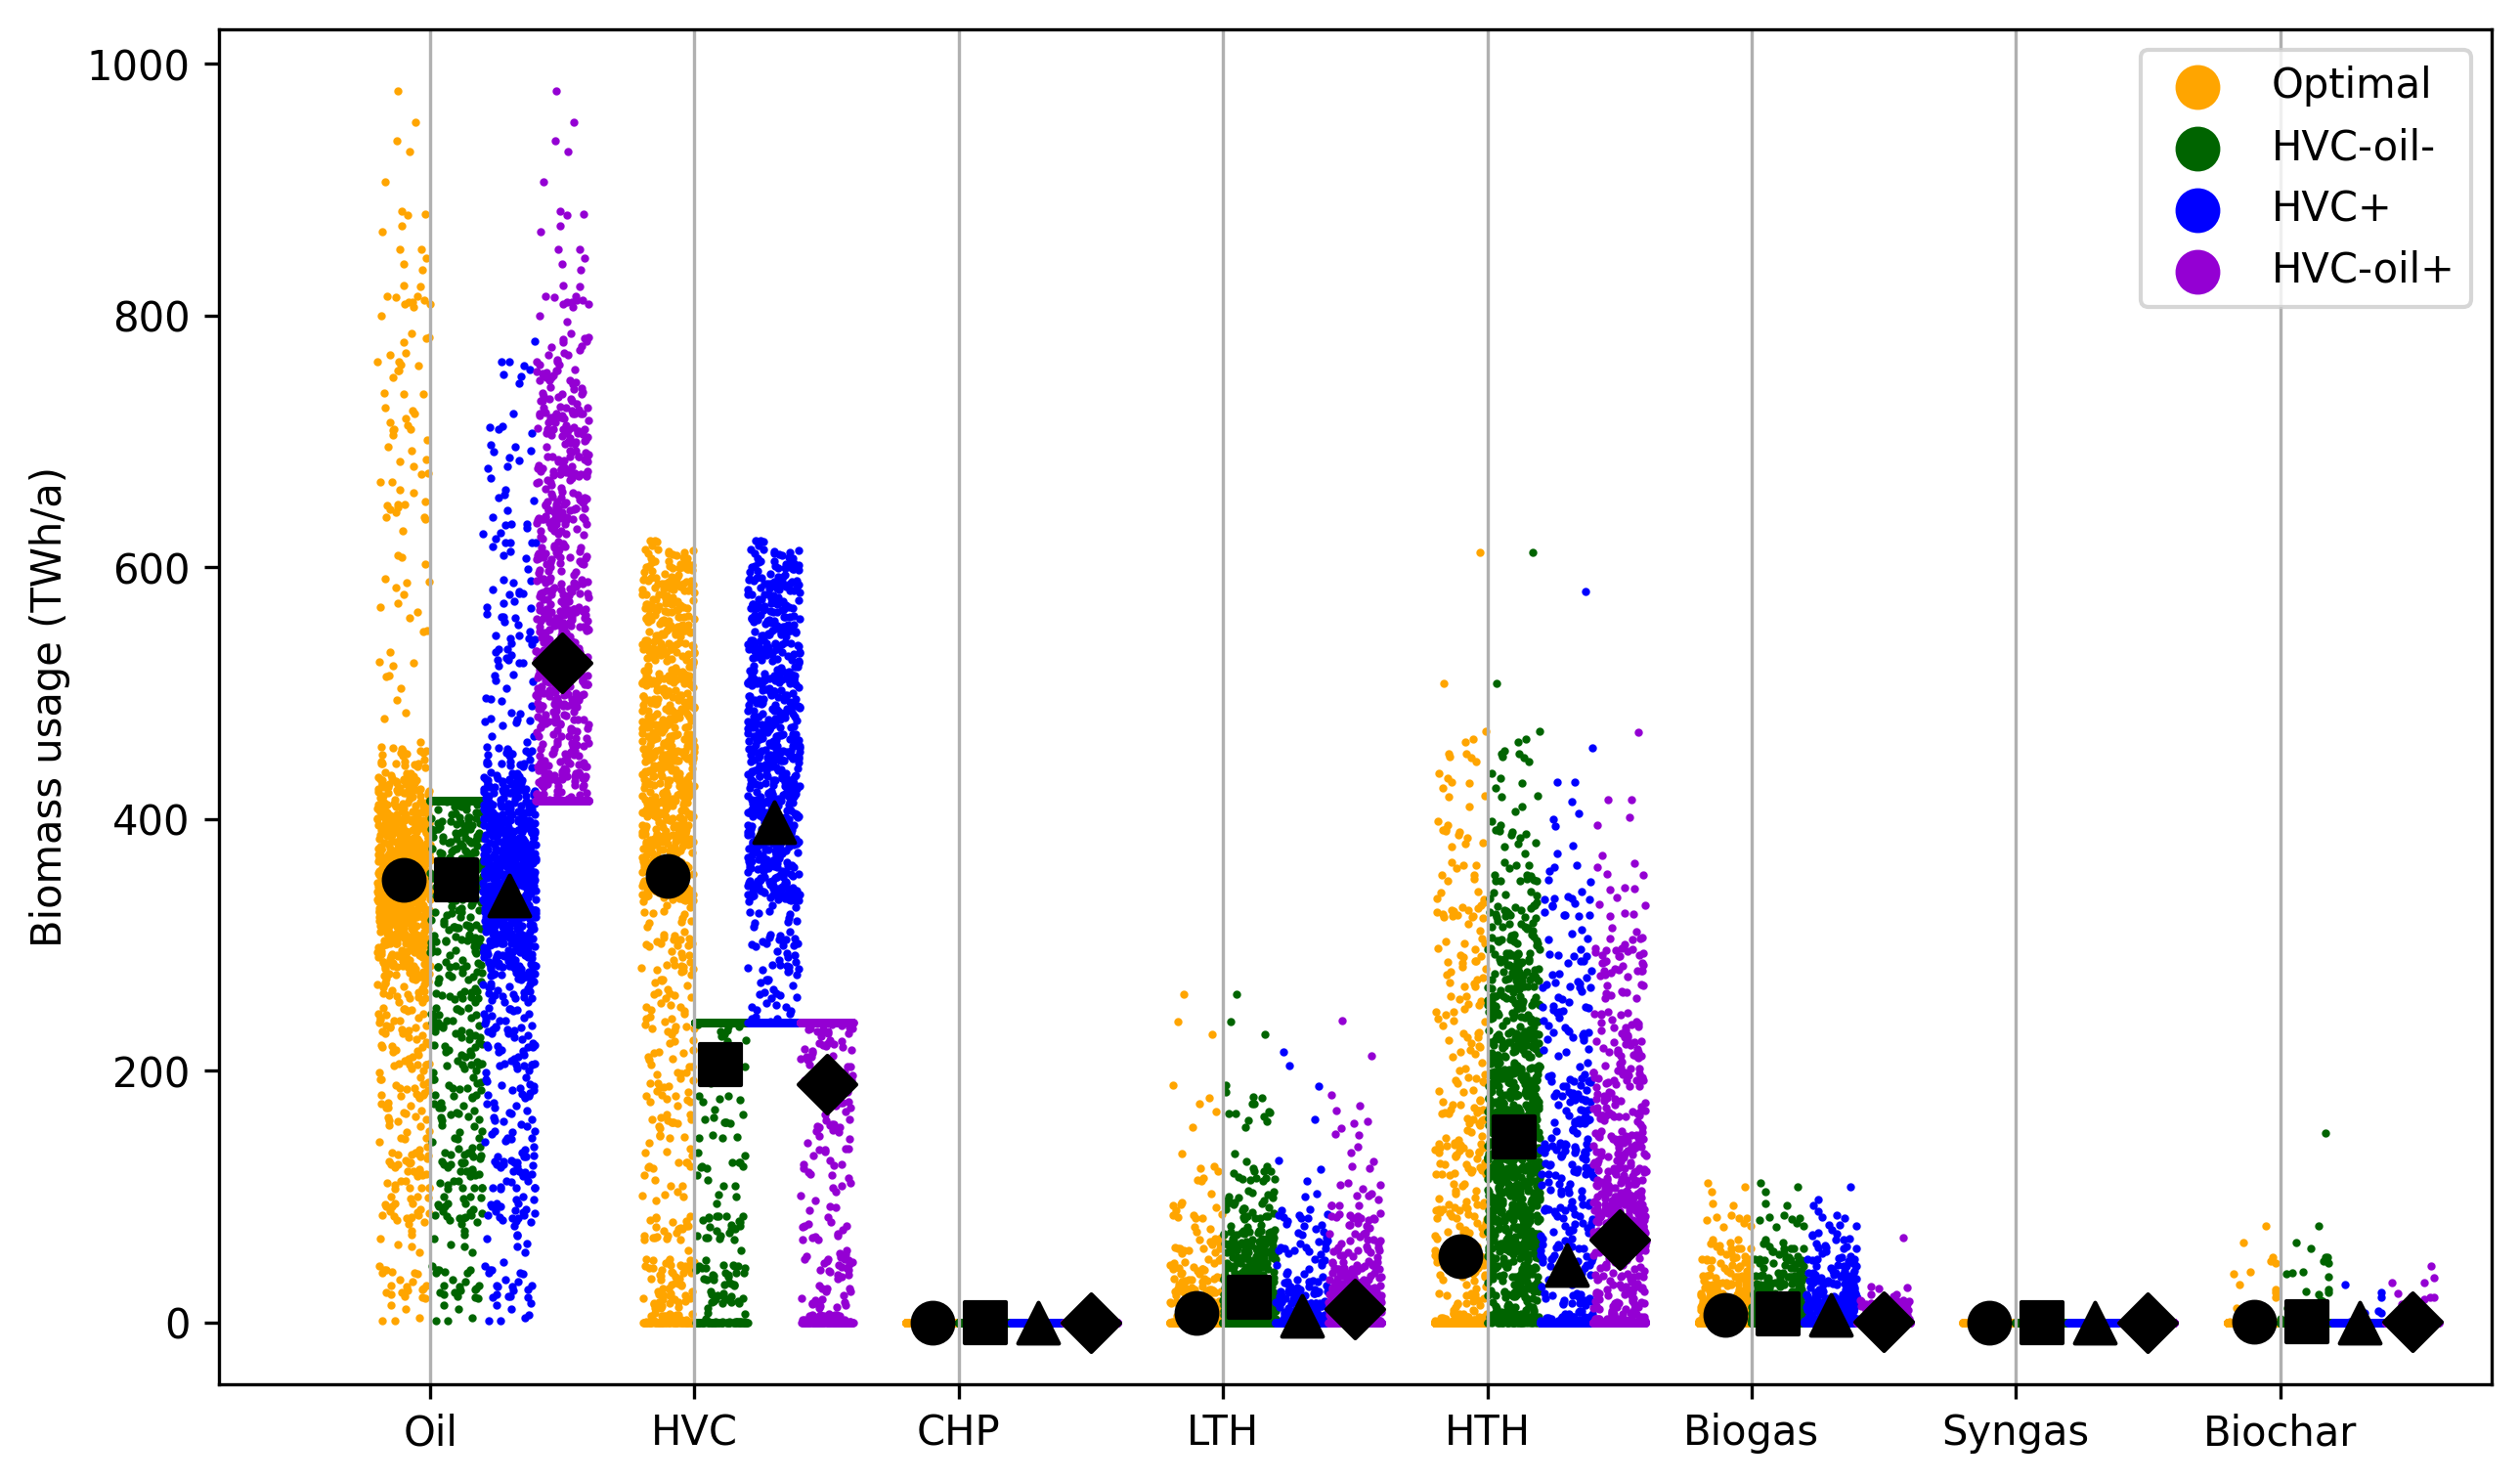

In [10]:
# Define colors and markers for the datasets
colors = ['orange', 'darkgreen', 'blue', 'darkviolet']
markers = ['o', 's', '^', 'D']
labels = ['Optimal', 'HVC-oil-', 'HVC+', 'HVC-oil+']
output_labels = ['Oil', 'HVC', 'CHP', 'LTH', 'HTH', 'Biogas', 'Syngas', 'Biochar']
ylabel = 'Biomass usage (TWh/a)'

# Remove the 'iteration' column from the dataframes
df_output_of_interest_optimal = df_output_of_interest_optimal_with_iteration.drop(columns=['iteration'])
df_output_of_interest_cluster_0 = df_output_of_interest_cluster_0_with_iteration.drop(columns=['iteration'])
df_output_of_interest_cluster_1 = df_output_of_interest_cluster_1_with_iteration.drop(columns=['iteration'])
df_output_of_interest_cluster_2 = df_output_of_interest_cluster_2_with_iteration.drop(columns=['iteration'])

# Randomness for jitter in scatter plots
randomness = np.random.random(len(df_output_of_interest_optimal))

# Plot the data
plt.figure(figsize=(10, 6), dpi=300)

# Iterate over each category (column) in the optimal DataFrame
for category_index, category_name in enumerate(df_output_of_interest_optimal.columns):
    
    # Loop through each dataset (optimal, cluster_0, cluster_1, cluster_2) along with its color, marker, and label
    for dataset_index, (df, color, marker, label) in enumerate(zip([df_output_of_interest_optimal, df_output_of_interest_cluster_0, df_output_of_interest_cluster_1, df_output_of_interest_cluster_2], colors, markers, labels)):
        
        # Calculate the x-position for scatter plot points, slightly offset for each dataset
        x_positions = [category_index - 0.2 + 0.2 * dataset_index] * len(df) + randomness * 0.2
        
        # Plot the scatter plot for each dataset at the calculated x-position
        plt.scatter(x_positions, df[category_name], s=1, alpha=1, c=color, label=label if category_index == 0 else "")
        
        # Calculate the mean value for the current category in the current dataset
        mean_value = np.mean(df[category_name])
        
        # Plot the mean value as a larger point with a specific marker
        plt.scatter([category_index - 0.1 + 0.2 * dataset_index], mean_value, s=100, c='black', edgecolor='k', marker=marker, zorder=5)


# Set x-axis tick labels
plt.xticks(range(len(df_output_of_interest_optimal.columns)), output_labels, rotation=0)
plt.xlim(-0.8, len(df_output_of_interest_optimal.columns) - 0.2)

# Set labels and legend
plt.ylabel(ylabel)
plt.legend(scatterpoints=1, fontsize=10, markerscale=10)

# Only print horizontal grid lines
plt.grid(axis='x')

# Show the plot
plt.show()
